<a href="https://colab.research.google.com/github/Shiyasalloor/Image_and_Video_processing_lab/blob/main/Set_3_Question_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import fftpack, signal
from scipy.signal import convolve2d
from PIL import Image
import imageio

In [2]:
def rgb2gray(img):
    if img.ndim == 3:
        return np.dot(img[..., :3], [0.2989, 0.5870, 0.1140])
    return img

def psnr(target, ref):
    mse = np.mean((target - ref) ** 2)
    if mse == 0:
        return float('inf')
    PIXEL_MAX = 255.0
    return 20 * np.log10(PIXEL_MAX / np.sqrt(mse))

# Gaussian kernel
def gaussian_kernel(size=21, sigma=5):
    ax = np.linspace(-(size // 2), size // 2, size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))
    kernel /= np.sum(kernel)
    return kernel

# Degrade image with blur + noise
def degrade_image(img, kernel, noise_sigma=10.0):
    blurred = convolve2d(img, kernel, mode='same', boundary='symm')
    noisy = blurred + np.random.normal(scale=noise_sigma, size=blurred.shape)
    noisy = np.clip(noisy, 0, 255)
    return noisy

In [3]:
def wiener_constant_ratio(degraded, kernel, K=0.01):
    m, n = degraded.shape
    pad_k = np.zeros_like(degraded)
    kh, kw = kernel.shape
    pad_k[:kh, :kw] = kernel
    pad_k = np.roll(np.roll(pad_k, -kh//2, axis=0), -kw//2, axis=1)

    G = fftpack.fft2(degraded)
    H = fftpack.fft2(pad_k)

    H_conj = np.conj(H)
    denom = (np.abs(H)**2 + K)
    F_hat = (H_conj / denom) * G

    f_hat = np.real(fftpack.ifft2(F_hat))
    return np.clip(f_hat, 0, 255)

In [4]:
def wiener_autocorrelation(degraded, kernel, noise_sigma=10.0):
    m, n = degraded.shape
    pad_k = np.zeros_like(degraded)
    kh, kw = kernel.shape
    pad_k[:kh, :kw] = kernel
    pad_k = np.roll(np.roll(pad_k, -kh//2, axis=0), -kw//2, axis=1)

    G = fftpack.fft2(degraded)
    H = fftpack.fft2(pad_k)

    N = np.abs(fftpack.fft2(np.random.normal(scale=noise_sigma, size=degraded.shape)))**2

    autocorr = signal.correlate2d(degraded, degraded, mode='same')
    Sf = np.abs(fftpack.fft2(autocorr))

    H_conj = np.conj(H)
    denom = (np.abs(H)**2 + (N / (Sf + 1e-6)))
    F_hat = (H_conj / denom) * G

    f_hat = np.real(fftpack.ifft2(F_hat))
    return np.clip(f_hat, 0, 255)

In [5]:
def main():
    # Load image
    try:
        img = imageio.imread('/content/dog.png')
    except FileNotFoundError:
        from scipy import misc
        img = misc.face(gray=True)  # fallback test image
    img = rgb2gray(img).astype(np.float64)

    if img.max() <= 1.0:
        img = img * 255.0

    # Create degradation
    kernel = gaussian_kernel(size=21, sigma=3)
    noise_sigma = 15
    degraded = degrade_image(img, kernel, noise_sigma=noise_sigma)

    # Wiener filtering
    restored_const = wiener_constant_ratio(degraded, kernel, K=0.01)
    restored_auto = wiener_autocorrelation(degraded, kernel, noise_sigma=noise_sigma)

    # Compute PSNR
    psnr_degraded = psnr(degraded, img)
    psnr_const = psnr(restored_const, img)
    psnr_auto = psnr(restored_auto, img)

    # Show results
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.title(f"Degraded\nPSNR={psnr_degraded:.2f} dB")
    plt.imshow(degraded, cmap='gray', vmin=0, vmax=255)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title(f"Wiener (Const K)\nPSNR={psnr_const:.2f} dB")
    plt.imshow(restored_const, cmap='gray', vmin=0, vmax=255)
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title(f"Wiener (Autocorr)\nPSNR={psnr_auto:.2f} dB")
    plt.imshow(restored_auto, cmap='gray', vmin=0, vmax=255)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

/tmp/ipython-input-1125862774.py:4: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread('/content/dog.png')


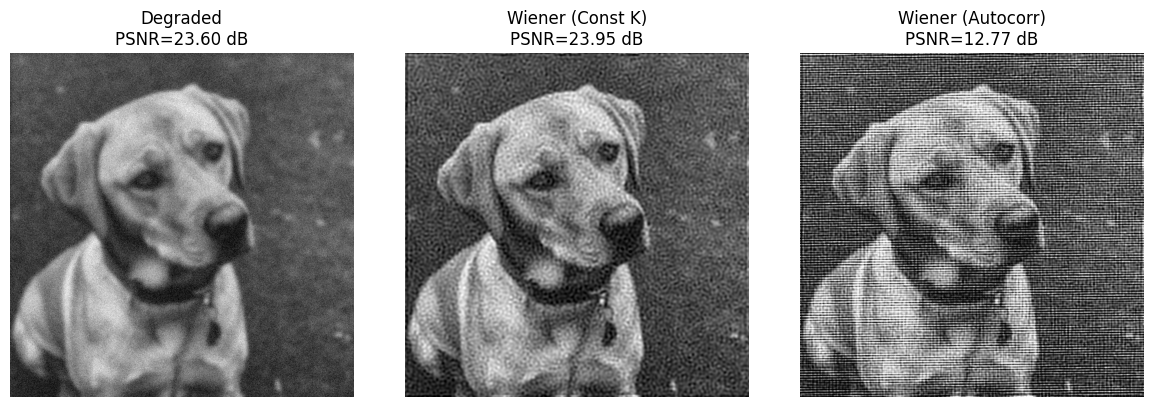

In [6]:
if __name__ == "__main__":
    main()